In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from matlabtools import Struct 
from fullwave2d.config.definitions import DATA_FDOP_DIR, DATA_BEAM_DIR, LPP_palette

from FW2D.io.interface import DataInterface
import h5py
from fullwave2d.core.wrapper import InputData

def get_ncrit(f0, angle=0.0):
    """
    Critical density for vacuum-frequency f0 [Hz] for
    O/X-mode and incidence angle [degrees].
    """
    # eps0 * m_e * (2 pi)² /e² [SI units] = 0.012404426
    return f0**2 * 0.012404426 * np.cos(np.deg2rad(angle))

In [2]:
it = 10 

flname = '/home/FO278650/Zone_Travail/HWAK/simu_hwak/4096_4096_C1.0_v2.h5'
with h5py.File(flname, 'r', libver='latest', swmr=True) as fl:

    C, kap = fl['params/C'][()], fl['params/kap'][()]
    nu, D = fl['params/nu'][()], fl['params/D'][()]
    
    #Construct the real space grid
    Lx, Ly = fl['params/Lx'][()], fl['params/Ly'][()]
    Npx, Npy = fl['params/Npx'][()], fl['params/Npy'][()]
    Nx, Ny, Nxh, Nyh = int(Npx/3)*2, int(Npy/3)*2, int(Npx/3), int(Npy/3)
    X, Y = np.arange(0,Nx)*Lx/Nx, np.arange(0,Ny)*Ly/Ny 
    #Construct Fourier grid
    dkx, dky = 2*np.pi/Lx, 2*np.pi/Ly
    kx, ky = np.r_[np.arange(0,int(Nx/2)+1)*dkx, np.arange(-int(Nx/2)+1, 0)*dkx],  np.arange(0, int(Ny/2)+1)*dky
    kx, ky = np.meshgrid(kx, ky, indexing='ij')
    ksqr=kx**2+ky**2

    uk = fl['fields/uk'][it]
    t = fl['fields/t'][it]
    
phi = np.fft.irfft2(uk[0,], norm='forward')
n = np.fft.irfft2(uk[1,], norm='forward')
ubar = np.real(np.fft.irfft(1j*kx[:Nxh+1, 0]*uk[0, :Nxh+1 , 0], norm='forward'))
rhos = 10e-3

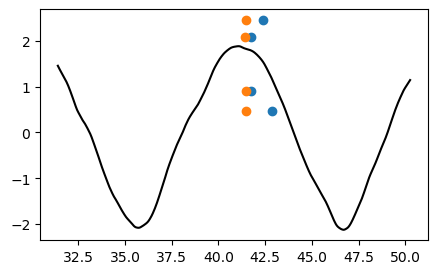

In [12]:
subdir, machine = 'HW_k_scan', 'altair'

dI = DataInterface(subdir, machine = machine)

fDop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
beam = Struct.from_mat(DATA_BEAM_DIR.joinpath(f'{subdir}.mat'), 'outp')

v_perp = (2 * np.pi * fDop.fDop) / (beam.k_perp * 2e2) / rhos * 2e-3

# for 
# for f0, angle, col in zip([53.5, 54, 54.8, 57, 60.5, ], [10, 15,20, 30, 40, 40], LPP_palette):

#     nr = np.mean(inp.ne.T, axis = 1)
#     nc = get_ncrit(f0 *1e9, angle = np.abs(angle))
#     ic = np.argmin(np.abs(nr - nc))
#     print(f0, X.size - 1024 + ic, ic)
#     xc.append(X[-1024+ic])
#     ax.plot(X[-1024+ic] * rhos * 1e2, ubar[-1024 +ic] , 'o', c = col, label = r'$f_0$ = %d GHz' %f0)

xc = np.array(xc) * rhos * 1e2

fig, ax = plt.subplots(figsize = (5, 3))
plt.plot(X[-1024:], ubar[-1024:], c = 'k')
ax.plot(beam.rho /rhos + X[-1024:].min(), v_perp, 'o')
ax.plot(xc, v_perp, 'o')


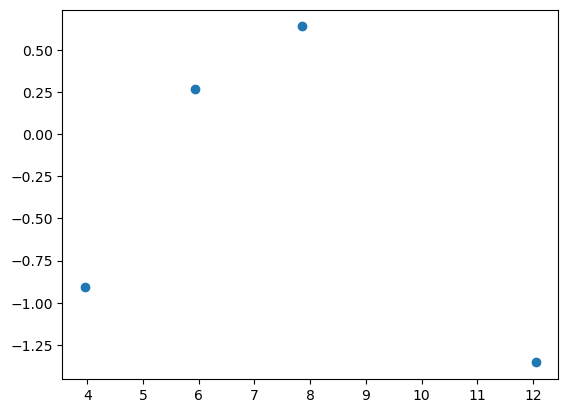

In [17]:
plt.plot(beam.k_perp * 200 * rhos, v_perp - ubar[-1024 +ic], 'o')

53.5 2251 545
54.0 2251 545
54.8 2250 544
57.0 2252 546
60.5 2254 548


Text(0, 0.5, '$v_{ZF}$')

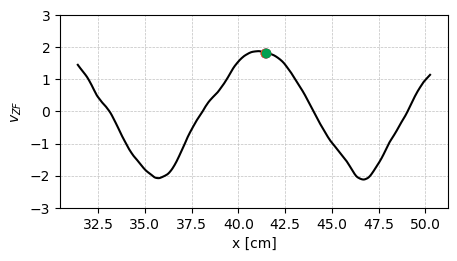

In [ ]:
fig, ax = plt.subplots(figsize = (5, 2.5))
rhos = 10e-3
ax.plot(X[-1024:] * rhos * 1e2, ubar[-1024:] , c = 'k')
xc = []
subdir, machine = 'HW_k', 'altair'

dI = DataInterface(subdir, machine = machine)

inp = InputData.load_pickle(dI.params.name[0], subdir, machine = machine)

F, T = np.array([53.5, 54, 54.8, 57, 60.5, ]), np.array([10, 15,20, 30, 40])

for f0, angle, col in zip(F, T, LPP_palette):
    nr = np.mean(inp.ne.T, axis = 1)
    nc = get_ncrit(f0 *1e9, angle = np.abs(angle))
    ic = np.argmin(np.abs(nr - nc))
    print(f0, X.size - 1024 + ic, ic)
    xc.append(X[-1024+ic])
    ax.plot(X[-1024+ic] * rhos * 1e2, ubar[-1024 +ic] , 'o', c = col, label = r'$f_0$ = %d GHz' %f0)

xc = np.array(xc) * rhos * 1e2


# ax.plot(beam.rho /rhos + X[-1024:].min()  , v_perp, 'Xm')
# ax.plot(xc, v_perp, 'Xr')

ax.set_ylim(-3, 3)
ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.set_xlabel('x [cm]')
ax.set_ylabel(r'$v_{ZF}$')
# ax.legend(loc = 2, ncol = 3, fontsize = 8)




In [76]:
from scipy import constants as cnst 
beam = Struct.from_mat(DATA_BEAM_DIR.joinpath(f'{subdir}.mat'), 'outp')

F, T = np.array([53.5, 54, 54.8, 57, 60.5, ]), np.array([10, 15,20, 30, 40])

kp = 4 * np.pi * F * 1e9 / cnst.c * np.sin(T * np.pi / 180) / 100 # cm-1

print(kp * 100 * rhos)
print(beam.k_perp * 200 * rhos)

[ 3.89415  5.8584   7.85636 11.94632 16.30092]
[ 5.17164  6.04244  5.59661 ...  6.56516 16.22902 12.04089]
